In [1]:
# python
import sys
import os
import awkward as ak
import coffea
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import matplotlib.pyplot as plt
import importlib

# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)

from sidm.tools import sidm_processor, llpnanoaodschema, utilities, scaleout
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)

# Set plot style
utilities.set_plot_style()
%matplotlib inline

In [ ]:
samples = [
    # "2Mu2E_100GeV_0p25GeV_2p0mm",
    # "2Mu2E_100GeV_1p2GeV_9p6mm",
    # "2Mu2E_100GeV_5p0GeV_40p0mm",
    # "2Mu2E_500GeV_0p25GeV_0p4mm",
    "2Mu2E_500GeV_1p2GeV_1p9mm",
    # "2Mu2E_500GeV_5p0GeV_8p0mm",
    # "2Mu2E_1000GeV_0p25GeV_0p2mm",
    # "2Mu2E_1000GeV_1p2GeV_0p96mm",
    # "2Mu2E_1000GeV_5p0GeV_4p0mm",
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", location_cfg="signal_2mu2e_v10.yaml", max_files=-1)

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True
)

channels = ["gen_leptons_final", "gen_leptons_born",]
hists    = ["genBS_genA_kinematics",]

p = sidm_processor.SidmProcessor(channels, hists, unweighted_hist=True,verbose=True)

out = {}
for i, sample in enumerate(samples):

    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)

    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

    ##Save output to a file!!
    out_file_name = "simplified_" + sample + ".coffea"
    coffea.util.save(output,out_file_name) 

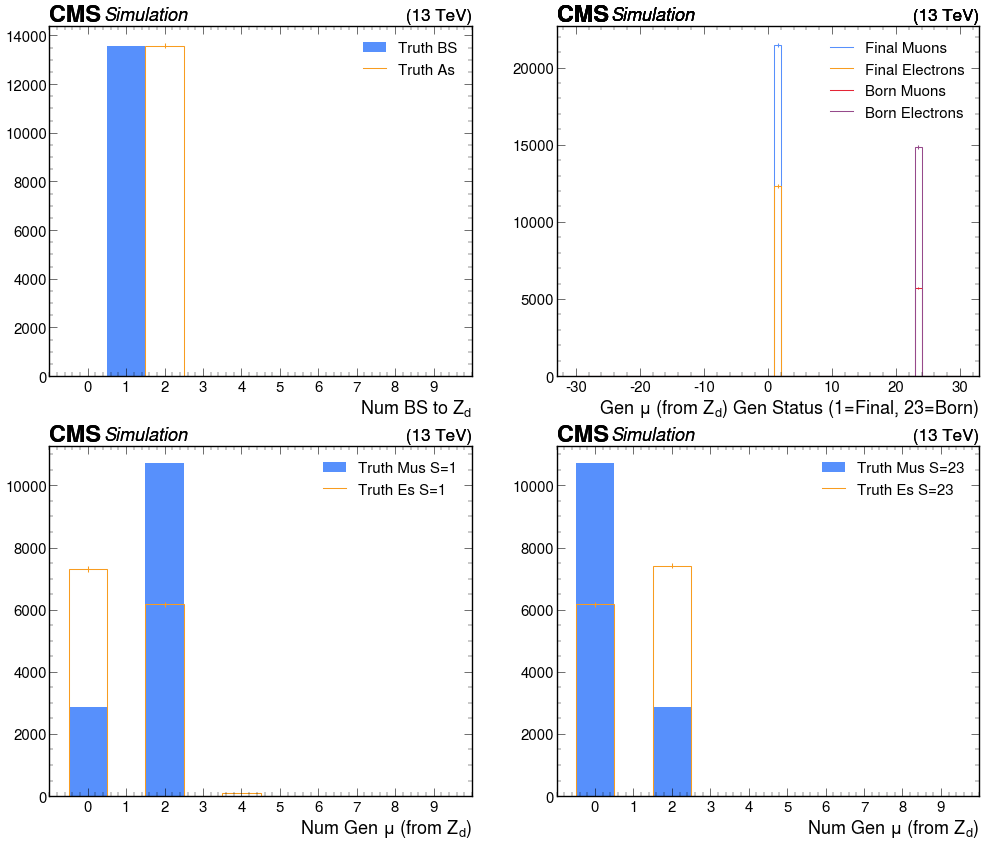

In [3]:
plt.subplots(2,2,figsize=(24,20))

plt.subplot(2,2,1)
utilities.plot(out[samples[0]]["hists"]["genBS_n"][channels[0], :],  histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genA_n"][channels[0], :])
plt.legend(["Truth BS", "Truth As",])

plt.subplot(2,2,2)
utilities.plot(out[samples[0]]["hists"]["genMus_fromA_status"][channels[0], :])
utilities.plot(out[samples[0]]["hists"]["genEs_fromA_status"][channels[0], :])
utilities.plot(out[samples[0]]["hists"]["genMus_fromA_status"][channels[1], :])
utilities.plot(out[samples[0]]["hists"]["genEs_fromA_status"][channels[1], :])
plt.legend(["Final Muons", "Final Electrons","Born Muons", "Born Electrons"])

plt.subplot(2,2,3)
utilities.plot(out[samples[0]]["hists"]["genMus_fromA_n"][channels[0], :],  histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genEs_fromA_n"][channels[0], :])
plt.legend(["Truth Mus S=1", "Truth Es S=1",])

plt.subplot(2,2,4)
utilities.plot(out[samples[0]]["hists"]["genMus_fromA_n"][channels[1], :],  histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genEs_fromA_n"][channels[1], :])
plt.legend(["Truth Mus S=23", "Truth Es S=23",])

plt.show()

# Bound State Kinematics

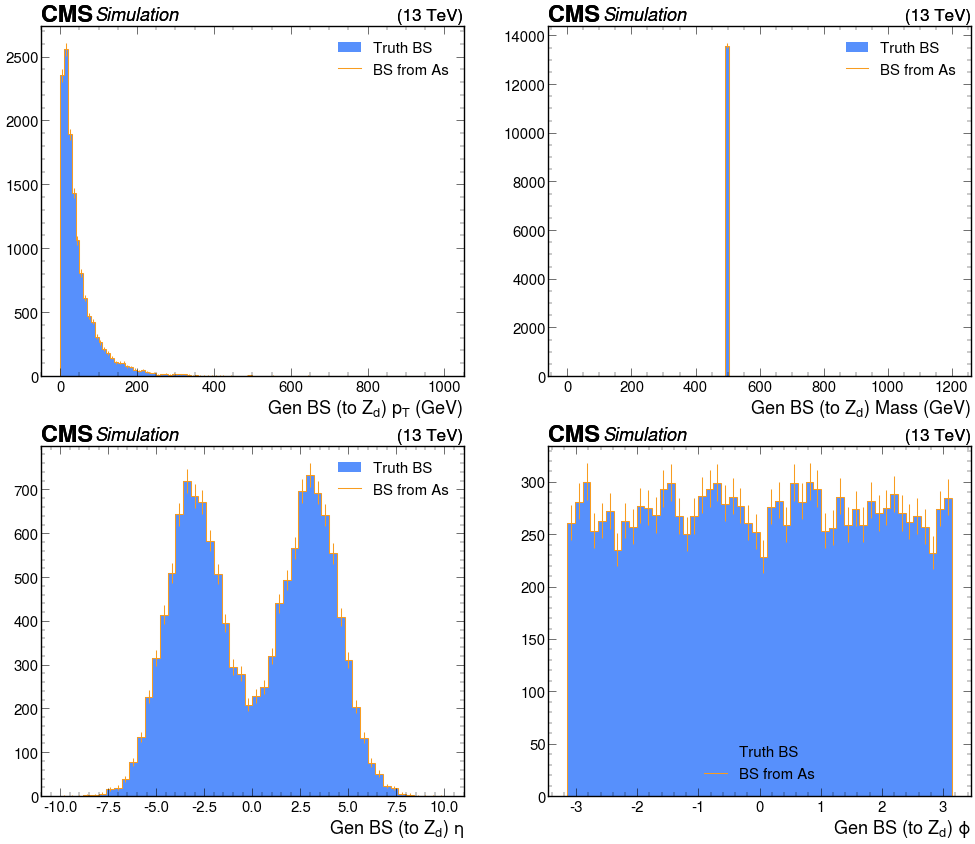

In [4]:
plt.subplots(2,2,figsize=(24,20))

plt.subplot(2,2,1)
utilities.plot(out[samples[0]]["hists"]["genBS_pt"][channels[0], :], histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genBS_from_genAs_pt"][channels[0], :])
plt.legend(["Truth BS", "BS from As",])

plt.subplot(2,2,2)
utilities.plot(out[samples[0]]["hists"]["genBS_mass"][channels[0], :], histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genBS_from_genAs_mass"][channels[0], :])
plt.legend(["Truth BS", "BS from As",])

plt.subplot(2,2,3)
utilities.plot(out[samples[0]]["hists"]["genBS_eta"][channels[0], :], histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genBS_from_genAs_eta"][channels[0], :])
plt.legend(["Truth BS", "BS from As",])

plt.subplot(2,2,4)
utilities.plot(out[samples[0]]["hists"]["genBS_phi"][channels[0], :], histtype="fill")
utilities.plot(out[samples[0]]["hists"]["genBS_from_genAs_phi"][channels[0], :])
plt.legend(["Truth BS", "BS from As",])

plt.show()

## Dark Photon Kinematics

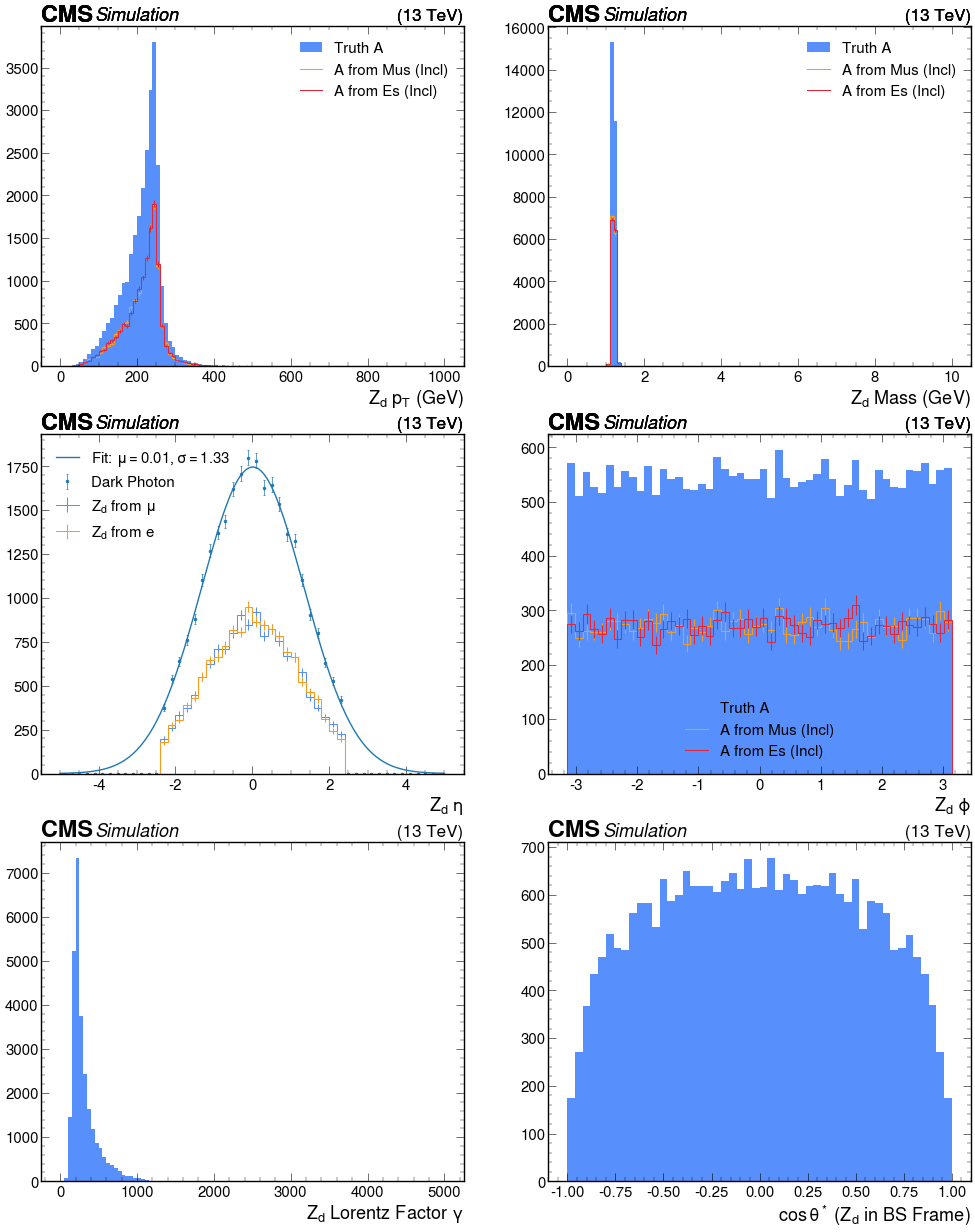

In [5]:
density  = False
plt.subplots(3,2,figsize=(24,30))

plt.subplot(3,2,1)
utilities.plot(out[samples[0]]["hists"]["genAs_pt"][channels[0], :], histtype="fill", density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genMus_pt"][channels[0], :], density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genEs_pt"][channels[0], :], density=density)
plt.legend(["Truth A", "A from Mus (Incl)","A from Es (Incl)",])

plt.subplot(3,2,2)
utilities.plot(out[samples[0]]["hists"]["genAs_mass"][channels[0], :], histtype="fill", density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genMus_mass"][channels[0], :], density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genEs_mass"][channels[0], :], density=density)
plt.legend(["Truth A", "A from Mus (Incl)","A from Es (Incl)",])

ax=plt.subplot(3,2,3)
utilities.plot_and_fit_gaussian(
    out[samples[0]]["hists"]["genAs_eta"][channels[0], :], 
    ax=ax, 
    color='tab:blue',
    label_prefix="Dark Photon",
    fit_range=(-2, 2),
    density=density
)
utilities.plot(out[samples[0]]["hists"]["genA_from_genMus_eta"][channels[0], :], density=density, label=r"$Z_d$ from $\mu$")
utilities.plot(out[samples[0]]["hists"]["genA_from_genEs_eta"][channels[0], :], density=density, label=r"$Z_d$ from $e$")
plt.legend(loc="best")

plt.subplot(3,2,4)
utilities.plot(out[samples[0]]["hists"]["genAs_phi"][channels[0], :], histtype="fill", density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genMus_phi"][channels[0], :], density=density)
utilities.plot(out[samples[0]]["hists"]["genA_from_genEs_phi"][channels[0], :], density=density)
plt.legend(["Truth A", "A from Mus (Incl)","A from Es (Incl)",])

plt.subplot(3,2,5)
utilities.plot(out[samples[0]]["hists"]["genAs_gamma"][channels[0], :],  histtype="fill")

plt.subplot(3,2,6)
utilities.plot(out[samples[0]]["hists"]["genAs_cosTheta_bsFrame"][channels[0], :],  histtype="fill")

plt.show()

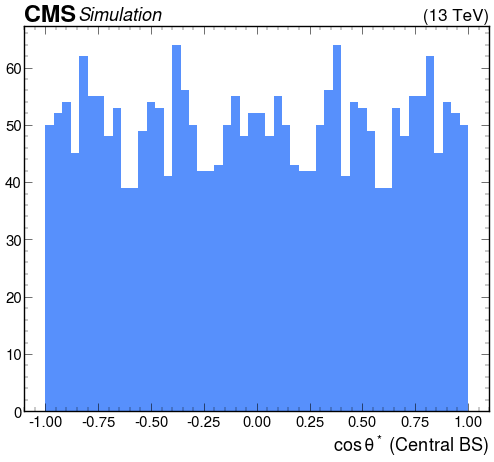

In [6]:
plt.subplots(1,1,figsize=(12,10))
plt.subplot(1,1,1)
utilities.plot(out[samples[0]]["hists"]["genAs_cosTheta_centralBS"][channels[0], :],  histtype="fill")
plt.show()

## Following is Status=23 Only to keep the study clean

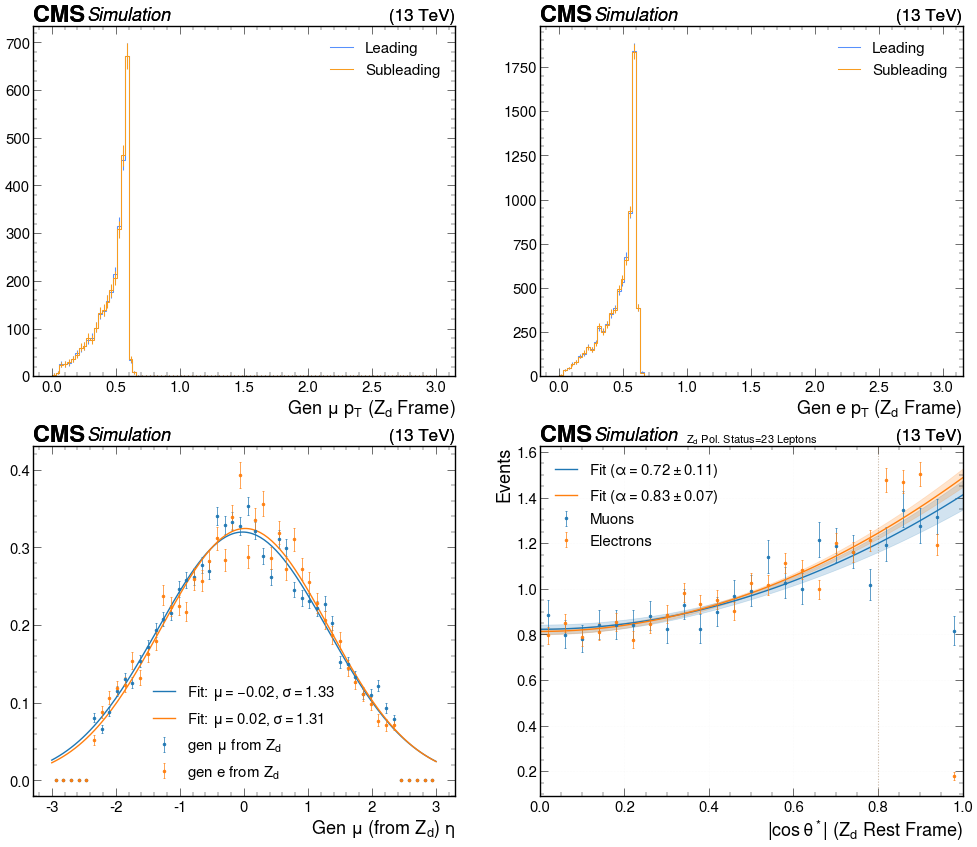

In [7]:
density  = True
plt.subplots(2,2,figsize=(24,20))

plt.subplot(2,2,1)
utilities.plot(out[samples[0]]["hists"]["genMu0_AFrame_pt"][channels[1], :])
utilities.plot(out[samples[0]]["hists"]["genMu1_AFrame_pt"][channels[1], :])
plt.legend(["Leading", "Subleading",])

plt.subplot(2,2,2)
utilities.plot(out[samples[0]]["hists"]["genE0_AFrame_pt"][channels[1], :])
utilities.plot(out[samples[0]]["hists"]["genE1_AFrame_pt"][channels[1], :])
plt.legend(["Leading", "Subleading",])

ax=plt.subplot(2,2,3)
utilities.plot_and_fit_gaussian(
    out[samples[0]]["hists"]["genMus_fromA_eta"][channels[0], :], 
    ax=ax, 
    color='tab:blue',
    label_prefix=r"gen $\mu$ from $Z_d$",
    fit_range=(-2, 2),
    density=density
)
utilities.plot_and_fit_gaussian(
    out[samples[0]]["hists"]["genEs_fromA_eta"][channels[0], :], 
    ax=ax, 
    color='tab:orange',
    label_prefix=r"gen $e$ from $Z_d$",
    fit_range=(-2, 2),
    density=density
)
plt.legend(loc="best")

ax = plt.subplot(2,2,4)
h_mu = out[samples[0]]["hists"]["genMu_AFrame_absCosTheta"][channels[1], :]
h_e  = out[samples[0]]["hists"]["genE_AFrame_absCosTheta"][channels[1], :]
utilities.plot_and_fit_polarization(
    h_mu, 
    ax=ax, 
    color='tab:blue', 
    label_prefix="Muons",
    fit_range=(0.0, 0.8),
    density=density,
)
utilities.plot_and_fit_polarization(
    h_e, 
    ax=ax, 
    color='tab:orange', 
    label_prefix="Electrons",
    fit_range=(0.0, 0.8),
    density=density
)
ax.set_xlabel(r"$|\cos \theta^*|$ ($Z_d$ Rest Frame)")
ax.set_ylabel("Events")
ax.set_title(r"$Z_d$ Pol. Status=23 Leptons", fontsize=16)
ax.set_xlim(0, 1.0)
ax.grid(True, alpha=0.1)
ax.legend(loc='upper left')

plt.show()

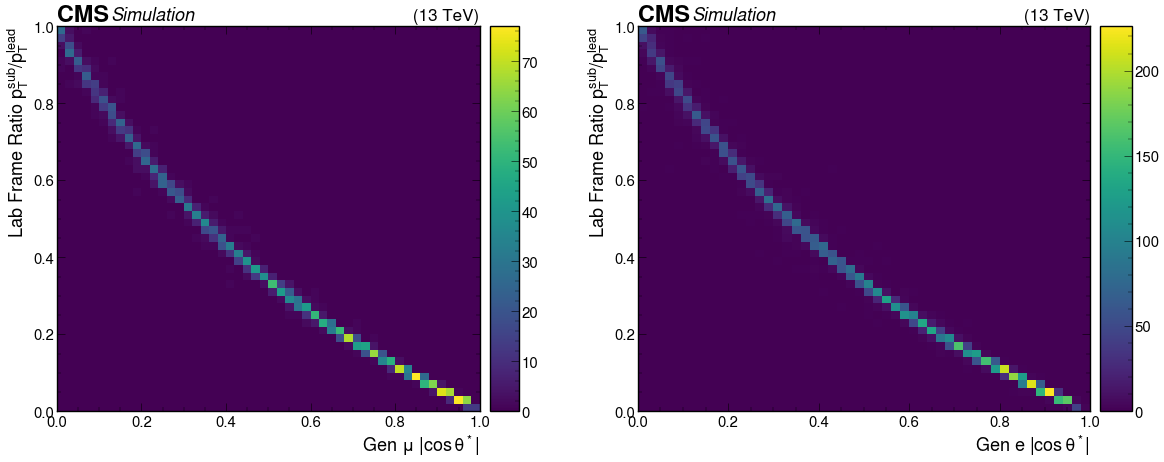

In [8]:
density  = True
plt.subplots(1,2,figsize=(24,10))

plt.subplot(1,2,1)
utilities.plot(out[samples[0]]["hists"]["genMu_ptRatio_vs_absCosTheta"][channels[1], :,:])

plt.subplot(1,2,2)
utilities.plot(out[samples[0]]["hists"]["genE_ptRatio_vs_absCosTheta"][channels[1], :,:])

plt.show()

## Comparison between Status=23 and Status=1

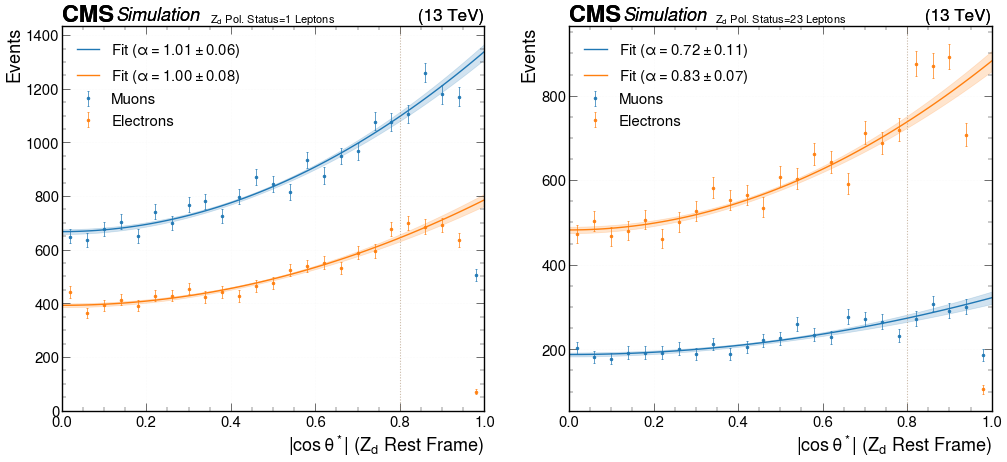

In [9]:
density = False
plt.subplots(1,2, figsize=(24, 10))

ax = plt.subplot(1,2,1)
h_mu = out[samples[0]]["hists"]["genMu_AFrame_absCosTheta"][channels[0], :]
h_e  = out[samples[0]]["hists"]["genE_AFrame_absCosTheta"][channels[0], :]
utilities.plot_and_fit_polarization(
    h_mu, 
    ax=ax, 
    color='tab:blue', 
    label_prefix="Muons",
    fit_range=(0.0, 0.8),
    density=density,
)
utilities.plot_and_fit_polarization(
    h_e, 
    ax=ax, 
    color='tab:orange', 
    label_prefix="Electrons",
    fit_range=(0.0, 0.8),
    density=density
)
ax.set_xlabel(r"$|\cos \theta^*|$ ($Z_d$ Rest Frame)")
ax.set_ylabel("Events")
ax.set_title(r"$Z_d$ Pol. Status=1 Leptons", fontsize=16)
ax.set_xlim(0, 1.0)
ax.grid(True, alpha=0.1)
ax.legend(loc='upper left')

ax = plt.subplot(1,2,2)
h_mu = out[samples[0]]["hists"]["genMu_AFrame_absCosTheta"][channels[1], :]
h_e  = out[samples[0]]["hists"]["genE_AFrame_absCosTheta"][channels[1], :]
utilities.plot_and_fit_polarization(
    h_mu, 
    ax=ax, 
    color='tab:blue', 
    label_prefix="Muons",
    fit_range=(0.0, 0.8),
    density=density,
)
utilities.plot_and_fit_polarization(
    h_e, 
    ax=ax, 
    color='tab:orange', 
    label_prefix="Electrons",
    fit_range=(0.0, 0.8),
    density=density
)
ax.set_xlabel(r"$|\cos \theta^*|$ ($Z_d$ Rest Frame)")
ax.set_ylabel("Events")
ax.set_title(r"$Z_d$ Pol. Status=23 Leptons", fontsize=16)
ax.set_xlim(0, 1.0)
ax.grid(True, alpha=0.1)
ax.legend(loc='upper left')

plt.show()

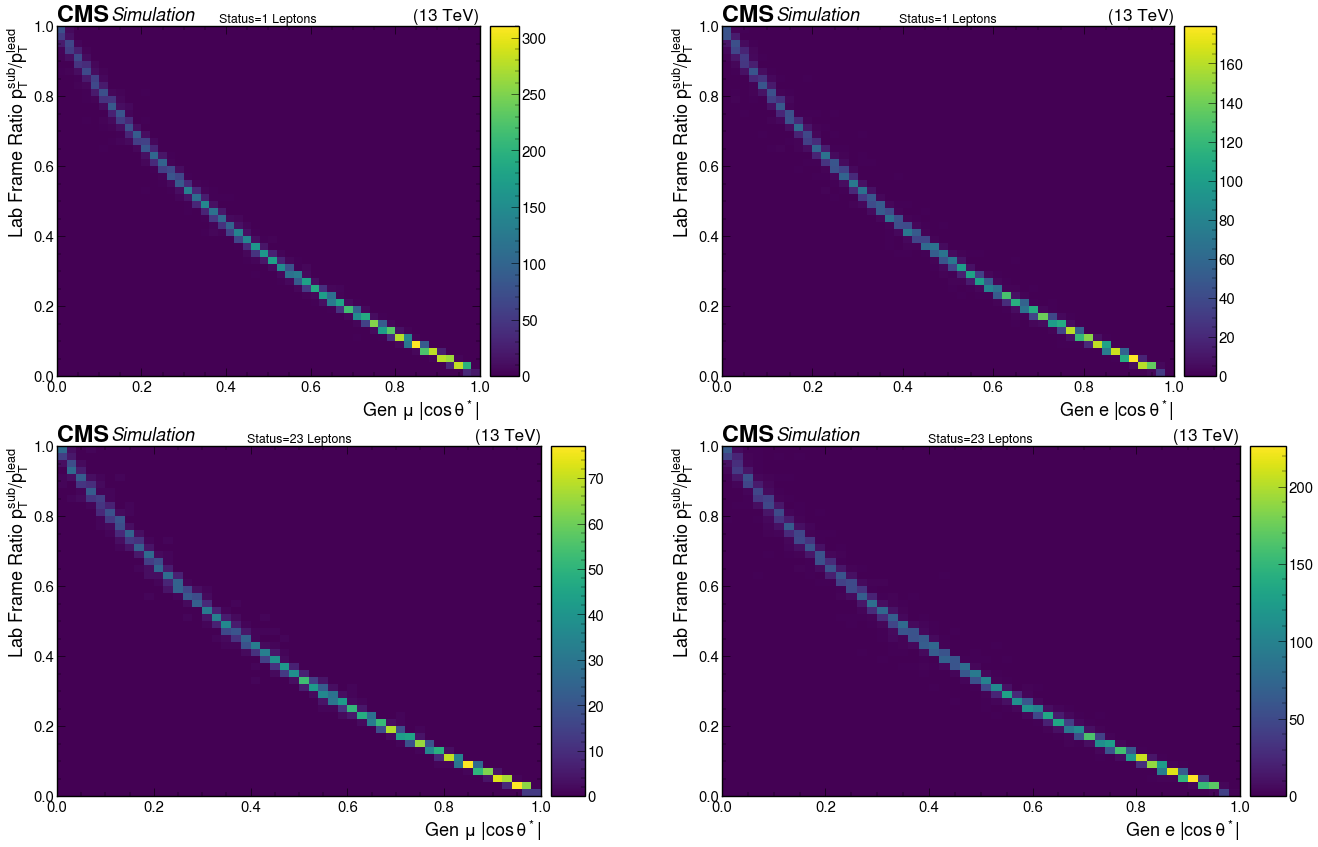

In [10]:
plt.subplots(2,2, figsize=(24,20))

plt.subplot(2,2,1)
utilities.plot(out[samples[0]]["hists"]["genMu_ptRatio_vs_absCosTheta"][channels[0], :,:])
plt.title("Status=1 Leptons", fontsize=18)

plt.subplot(2,2,2)
utilities.plot(out[samples[0]]["hists"]["genE_ptRatio_vs_absCosTheta"][channels[0], :,:])
plt.title("Status=1 Leptons", fontsize=18)

plt.subplot(2,2,3)
utilities.plot(out[samples[0]]["hists"]["genMu_ptRatio_vs_absCosTheta"][channels[1], :,:])
plt.title("Status=23 Leptons", fontsize=18)

plt.subplot(2,2,4)
utilities.plot(out[samples[0]]["hists"]["genE_ptRatio_vs_absCosTheta"][channels[1], :,:])
plt.title("Status=23 Leptons", fontsize=18)

plt.show()